<a href="https://colab.research.google.com/github/Gabzedu/trading-execution-analysis/blob/main/notebook/trading_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trading Study Analysis (2023–2024)

## 1. Problem Statement

This project analyses my personal trading activity during my early trading study period, covering entries recorded between 2023 and 2024.

The goal is to investigate my execution quality and decision-making during this beginning phase, focusing on the gap between planned and actual outcomes rather than overall profitability.

**Key questions:**
- How does my realized Risk-Reward Ratio (RRR) compare to the RRR I originally planned for each trade?
- How does performance vary across different account/environment types (backtesting, demo, and live funded accounts)?
- Is there a measurable change in performance immediately following a losing trade (post-loss sequence)?

> **Note:** This was my first structured trading journal. The raw data contains manual entry inconsistencies (typos, missing values, mixed account categories) that are identified and addressed explicitly during the data cleaning stage below - and that is the challenge of this project.

## 2. Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving trading_2023_2024.xlsx to trading_2023_2024.xlsx


In [2]:
import openpyxl

# Load the Excel file; data_only=True returns calculated values
# (e.g. 50.0) instead of formulas (e.g. "=A1+A2")
wb = openpyxl.load_workbook('trading_2023_2024.xlsx', data_only=True)

# Access the specific sheet that contains the trade data
ws = wb['2023_2024']

# Confirm the sheet dimensions
print('Number of rows:', ws.max_row)
print('Number of columns:', ws.max_column)

Number of rows: 218
Number of columns: 60


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [3]:
# Print all non-empty header cells in rows 7 and 8, to map out
# which column number corresponds to which field name
for row_number in [7, 8]:
    print(f'--- Row {row_number} ---')
    for col_number in range(1, 61):
        value = ws.cell(row=row_number, column=col_number).value
        if value is not None:
            print(col_number, value)

--- Row 7 ---
2 Backtesting
3 2
4 2ª F
5 30 de Janeiro 2023
6 Tarde
8 GBPUSD
9 Breakout
10 1m
11 long
12 L
13 4950
14 49.5
15 0.01
16 0.01
17 1.24002
18 1.23976
19 0.00025999999999992696
20 49.5
21 1.2408
22 0.0007800000000000029
23 148.50000000004226
24 3.000000000000854
25 30 de Janeiro 2023
26 1.23976
27 0
28 0
29 -49.5
30 -49.5
31 -0.00025999999999992696
32 -0.01
33 4900.5
40 4ª F
41 Noite
42 Bandeira
43 8h
46 n/a
47 Next
48 Exotics
49 Greed
51 0.2
52 0.2
53 1
55 GBPCHF
56 Majors
59 B
60 Boa entrada - Com alguma estratégia - Alguma Probabilidade 
--- Row 8 ---
2 Backtesting
3 3
4 2ª F
5 30 de Janeiro 2023
6 Tarde
8 CADJPY
9 Breakout
10 1m
11 long
12 W
13 4900.5
14 49.005
15 0.01
16 0.02
17 97.502
18 97.445
19 0.05700000000000216
20 49.005
21 97.675
22 0.17300000000000182
23 148.73447368420648
24 3.0350877192981627
25 30 de Janeiro 2023
26 97.675
27 0
28 0
29 148.73447368420648
30 148.73447368420648
31 0.17300000000000182
32 0.030350877192981626
33 5049.234473684206
40 5ª F
42 Conti

In [4]:
# Print the first 12 rows to find where the headers actually are now
# (row numbers may have shifted after editing the Excel file)
for row_number in range(1, 13):
    print(f'--- Row {row_number} ---')
    for col_number in range(1, 15):
        value = ws.cell(row=row_number, column=col_number).value
        if value is not None:
            print(col_number, value)

--- Row 1 ---
--- Row 2 ---
2 ACOUNT
3 Nº
T
4 WEEK DAY
5 ENTRY DAY
6 ZONE
7 PRODUCT GROUP
8 PRODUCT
9 STRATEGY
10 TIMEFRAME
11 S\L
12 W
L
13 Starting Position
--- Row 3 ---
13 Account
Funds
14 €
Risk
--- Row 4 ---
1 ,
--- Row 5 ---
--- Row 6 ---
2 Backtesting
3 1
4 2ª F
5 30 de Janeiro 2023
6 Tarde
8 AUDNZD
9 Breakout
10 3m
11 short
12 L
13 5000
14 50
--- Row 7 ---
2 Backtesting
3 2
4 2ª F
5 30 de Janeiro 2023
6 Tarde
8 GBPUSD
9 Breakout
10 1m
11 long
12 L
13 4950
14 49.5
--- Row 8 ---
2 Backtesting
3 3
4 2ª F
5 30 de Janeiro 2023
6 Tarde
8 CADJPY
9 Breakout
10 1m
11 long
12 W
13 4900.5
14 49.005
--- Row 9 ---
2 Testing em tempo real 
3 4
4 3ª F
5 31 de janeiro 2023
6 Manhã
8 GBPUSD
9 Breakout
10 3m
11 short
12 W
13 5049.234473684206
14 50.492344736842064
--- Row 10 ---
2 Testing em tempo real 
3 5
4 5ª F
5 2 de Fevereiro 2023
6 Manhã
8 GBPUSD
9 Breakout
10 15m
11 short
12 W
13 5201.646551315791
14 52.01646551315791
--- Row 11 ---
2 Backtesting
3 6
4 6ª F
5 3 de Fevereiro 2023
6 Manhã


In [5]:
# Print all header cells in rows 2 and 3, across all 60 columns,
# to complete the column map before writing any cleaning logic
for row_number in [2, 3]:
    print(f'--- Row {row_number} ---')
    for col_number in range(1, 61):
        value = ws.cell(row=row_number, column=col_number).value
        if value is not None:
            print(col_number, value)

--- Row 2 ---
2 ACOUNT
3 Nº
T
4 WEEK DAY
5 ENTRY DAY
6 ZONE
7 PRODUCT GROUP
8 PRODUCT
9 STRATEGY
10 TIMEFRAME
11 S\L
12 W
L
13 Starting Position
18 Stop Loss
21 Take Profit
25 Close Position
33 
Print Close
--- Row 3 ---
13 Account
Funds
14 €
Risk
15 %
Risk
16 Lot
17 Position
entry
18 Max 
Loss
19 Pips
20 € 
Loss
21 Take Profit
22 Pips
23 € 
Gain
24 RRR
25 Day
Close
26 Closing
price
27 COMMISSION
28 SWAP
29 PROFIT
30 NET PROFIT
31 PIPS CLOSE
32 RRR
55 Currency
56 Grup
57 Avaliação das Entradas:


In [6]:
# Find the last row that actually contains trade data
# (looks for a value in the ACCOUNT column, starting from row 6)
last_row_with_data = None
for row_number in range(6, ws.max_row + 1):
    if ws.cell(row=row_number, column=2).value is not None:
        last_row_with_data = row_number

print('Last row with data:', last_row_with_data)

Last row with data: 163


## 3. Data Cleaning & Transformation

In [7]:
# Column map: field name -> column number in the worksheet
COLUMNS = {
    'account': 2,
    'trade_number': 3,
    'week_day': 4,
    'entry_date': 5,
    'zone': 6,
    'product_group': 7,
    'product': 8,
    'strategy': 9,
    'timeframe': 10,
    'direction': 11,
    'result': 12,
    'account_funds': 13,
    'risk_eur': 14,
    'risk_pct': 15,
    'lot': 16,
    'rrr_planned': 24,
    'commission': 27,
    'swap': 28,
    'profit': 29,
    'net_profit': 30,
    'rrr_realized': 32,
}

In [8]:
trades = []

for row_number in range(6, 164):  # 164 porque o range não inclui o último número
    account = ws.cell(row=row_number, column=COLUMNS['account']).value

    # Skip empty rows
    if account is None:
        continue

    trade = {}
    for field_name, col_number in COLUMNS.items():
        trade[field_name] = ws.cell(row=row_number, column=col_number).value

    trades.append(trade)

df = pd.DataFrame(trades)

print('Number of trades loaded:', len(df))
df.head()

Number of trades loaded: 158


,account,trade_number,week_day,entry_date,zone,product_group,product,strategy,timeframe,direction,...,account_funds,risk_eur,risk_pct,lot,rrr_planned,commission,swap,profit,net_profit,rrr_realized
0,Backtesting,1,2ª F,30 de Janeiro 2023,Tarde,None,AUDNZD,Breakout,3m,short,...,5000.000000,50.000000,0.01,0.01,2.398148,0.0,0.0,-50.000000,-50.000000,-0.010000
1,Backtesting,2,2ª F,30 de Janeiro 2023,Tarde,None,GBPUSD,Breakout,1m,long,...,4950.000000,49.500000,0.01,0.01,3.000000,0.0,0.0,-49.500000,-49.500000,-0.010000
2,Backtesting,3,2ª F,30 de Janeiro 2023,Tarde,None,CADJPY,Breakout,1m,long,...,4900.500000,49.005000,0.01,0.02,3.035088,0.0,0.0,148.734474,148.734474,0.030351
3,Testing em tempo real,4,3ª F,31 de janeiro 2023,Manhã,None,GBPUSD,Breakout,3m,short,...,5049.234474,50.492345,0.01,0.50,3.018519,0.0,0.0,152.412078,152.412078,0.030185
4,Testing em tempo real,5,5ª F,2 de Fevereiro 2023,Manhã,None,GBPUSD,Breakout,15m,short,...,5201.646551,52.016466,0.01,0.01,2.996269,0.0,0.0,155.855305,155.855305,0.029963


In [9]:
dia_semana_map = {
    '2ª F': 'Monday',
    '3ª F': 'Tuesday',
    '4ª F': 'Wednesday',
    '5ª F': 'Thursday',
    '6ª F': 'Friday',
    'Sábado': 'Saturday',
    'Domingo': 'Sunday'
}

df['week_day'] = df['week_day'].replace(dia_semana_map)

In [10]:
df['week_day'].unique()

array(['Monday', 'Tuesday', 'Thursday', 'Friday', 'Wednesday'],
      dtype=object)

In [11]:
# Round euro values to cents (2 decimal places)
df['risk_eur'] = df['risk_eur'].round(2)
df['profit'] = df['profit'].round(2)
df['net_profit'] = df['net_profit'].round(2)

df.head()

,account,trade_number,week_day,entry_date,zone,product_group,product,strategy,timeframe,direction,...,account_funds,risk_eur,risk_pct,lot,rrr_planned,commission,swap,profit,net_profit,rrr_realized
0,Backtesting,1,Monday,30 de Janeiro 2023,Tarde,None,AUDNZD,Breakout,3m,short,...,5000.000000,50.00,0.01,0.01,2.398148,0.0,0.0,-50.00,-50.00,-0.010000
1,Backtesting,2,Monday,30 de Janeiro 2023,Tarde,None,GBPUSD,Breakout,1m,long,...,4950.000000,49.50,0.01,0.01,3.000000,0.0,0.0,-49.50,-49.50,-0.010000
2,Backtesting,3,Monday,30 de Janeiro 2023,Tarde,None,CADJPY,Breakout,1m,long,...,4900.500000,49.00,0.01,0.02,3.035088,0.0,0.0,148.73,148.73,0.030351
3,Testing em tempo real,4,Tuesday,31 de janeiro 2023,Manhã,None,GBPUSD,Breakout,3m,short,...,5049.234474,50.49,0.01,0.50,3.018519,0.0,0.0,152.41,152.41,0.030185
4,Testing em tempo real,5,Thursday,2 de Fevereiro 2023,Manhã,None,GBPUSD,Breakout,15m,short,...,5201.646551,52.02,0.01,0.01,2.996269,0.0,0.0,155.86,155.86,0.029963


In [12]:
# Standardize the result column: strip whitespace, force uppercase,
# and mark anything that isn't 'W' or 'L' as missing (NaN)
df['result'] = df['result'].astype(str).str.strip().str.upper()
df.loc[~df['result'].isin(['W', 'L']), 'result'] = pd.NA

print(df['result'].value_counts(dropna=False))

result
L       94
W       57
<NA>     7
Name: count, dtype: int64


In [13]:
# Strip whitespace first, then see all distinct account values and their counts
df['account'] = df['account'].astype(str).str.strip()
print(df['account'].value_counts())

account
FTMO challenge 1                                                 61
Fusion demo                                                      27
Backtesting                                                      20
Testing em tempo real                                            17
2º MT Ic Market demo                                             14
MFF Challenge                                                     9
3º MT Ic Market demo                                              6
Trading view (não consegui encontrar no Fusion o wheat)           2
Trading view (não consegui apanhar a tempo que pôr no fusion)     2
Name: count, dtype: int64


In [14]:
ENVIRONMENT_MAP = {
    'Backtesting': 'Backtesting',
    'Testing em tempo real': 'Demo',
    '2º MT Ic Market demo': 'Demo',
    '3º MT Ic Market demo': 'Demo',
    'Fusion demo': 'Demo',
    'Trading view (não consegui encontrar no Fusion o wheat)': 'Demo',
    'Trading view (não consegui apanhar a tempo que pôr no fusion)': 'Demo',
    'MFF Challenge': 'Live Funded Account',
    'FTMO challenge 1': 'Live Funded Account',
}

df['environment'] = df['account'].map(ENVIRONMENT_MAP)

print(df['environment'].value_counts(dropna=False))

environment
Live Funded Account    70
Demo                   68
Backtesting            20
Name: count, dtype: int64


In [15]:
# Check all distinct values in the direction column before cleaning
print(df['direction'].value_counts(dropna=False))

direction
Short    51
Long     46
short    34
long     27
Name: count, dtype: int64


In [16]:
# Standardize direction to lowercase (long/short are ordinary words,
# not acronyms, so lowercase reads more naturally than uppercase)
df['direction'] = df['direction'].astype(str).str.strip().str.lower()

print(df['direction'].value_counts(dropna=False))

direction
short    85
long     73
Name: count, dtype: int64


In [17]:
import re

# Extract the month word from each entry_date (the word between the day
# number and the year), to check for typos before parsing to a real date
def extract_month_word(date_text):
    match = re.search(r'de (\w+)', str(date_text))
    return match.group(1) if match else None

print(df['entry_date'].apply(extract_month_word).value_counts())

entry_date
Junho        33
Julho        27
Maio         25
Fevereiro    20
Abril        16
Agosto       13
Novembro      7
Março         5
Janeiro       5
Dezembro      3
Mario         1
janeiro       1
Setembro      1
Julhp         1
Name: count, dtype: int64


In [18]:
# Map month names (lowercase) to month numbers.
# Includes two known typos found in the raw data: 'mario' -> March,
# 'julhp' -> July. Documenting them here instead of silently fixing them.
MONTH_MAP = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'mario': 3,
    'abril': 4, 'maio': 5, 'junho': 6, 'julho': 7, 'julhp': 7,
    'agosto': 8, 'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12,
}

def parse_entry_date(date_text):
    match = re.search(r'(\d+) de (\w+) (\d{4})', str(date_text))
    if not match:
        return pd.NaT
    day, month_word, year = match.groups()
    month_number = MONTH_MAP.get(month_word.lower())
    if month_number is None:
        return pd.NaT
    return pd.Timestamp(year=int(year), month=month_number, day=int(day))

df['entry_date'] = df['entry_date'].apply(parse_entry_date)

# Confirm how many rows failed to parse (should be 0)
print('Rows with unparseable date:', df['entry_date'].isna().sum())
print(df['entry_date'].head())

Rows with unparseable date: 1
0   2023-01-30
1   2023-01-30
2   2023-01-30
3   2023-01-31
4   2023-02-02
Name: entry_date, dtype: datetime64[ns]


In [19]:
# Find the row(s) where entry_date failed to parse, and show the
# original text before it was overwritten, so we can see what's wrong
unparsed = df[df['entry_date'].isna()]
print(unparsed[['account', 'trade_number']])

              account  trade_number
157  FTMO challenge 1           158


In [20]:
# Find the exact worksheet row where trade_number equals 158,
# then print the raw entry_date text from the Excel file directly
for row_number in range(6, 164):
    if ws.cell(row=row_number, column=COLUMNS['trade_number']).value == 158:
        print('Excel row:', row_number)
        print('Raw entry_date value:', repr(ws.cell(row=row_number, column=COLUMNS['entry_date']).value))
        break

Excel row: 163
Raw entry_date value: '5 de Agosto  2024'


In [21]:
def parse_entry_date(date_text):
    # \s+ matches one or more spaces, protecting against double-space typos
    # like the one found in trade_number 158 ('5 de Agosto  2024')
    match = re.search(r'(\d+)\s+de\s+(\w+)\s+(\d{4})', str(date_text))
    if not match:
        return pd.NaT
    day, month_word, year = match.groups()
    month_number = MONTH_MAP.get(month_word.lower())
    if month_number is None:
        return pd.NaT
    return pd.Timestamp(year=int(year), month=month_number, day=int(day))

In [22]:
df['entry_date'] = df['entry_date'].apply(parse_entry_date)

print('Rows with unparseable date:', df['entry_date'].isna().sum())

Rows with unparseable date: 158


In [23]:
# Reload entry_date from the original worksheet (the df column was
# already converted to dates in a previous step, so we can't reuse it —
# text parsing needs the original text, not an already-parsed date)
raw_entry_dates = []
for row_number in range(6, 164):
    account = ws.cell(row=row_number, column=COLUMNS['account']).value
    if account is None:
        continue
    raw_entry_dates.append(ws.cell(row=row_number, column=COLUMNS['entry_date']).value)

df['entry_date'] = raw_entry_dates
df['entry_date'] = df['entry_date'].apply(parse_entry_date)

print('Rows with unparseable date:', df['entry_date'].isna().sum())

Rows with unparseable date: 0


In [24]:
# Check all distinct values in the product column, sorted alphabetically
# so similar-looking entries end up near each other
print(df['product'].astype(str).str.strip().value_counts().sort_index())

product
AUDCAD       3
AUDCHF       2
AUDJPY       3
AUDNZD       2
AUDUSD      11
CADJPY       7
EURAUD       1
EURCAD       1
EURCHF       2
EURGBP       3
EURJPY       2
EURNOK       1
EURSGD       1
EURUSD      40
GBPAUD       3
GBPCAD       5
GBPJPY       2
GBPNOK       1
GBPUSD      39
NZDUSD       3
Nasdaq       1
UK100        5
USDCAD      10
USDCHF       1
USDCNH       1
USDJPY       4
USDSGD       1
Wheatusd     2
XAUUSD       1
Name: count, dtype: int64


In [25]:
df['product'] = df['product'].astype(str).str.strip().str.upper()

print(df['product'].value_counts().sort_index())

product
AUDCAD       3
AUDCHF       2
AUDJPY       3
AUDNZD       2
AUDUSD      11
CADJPY       7
EURAUD       1
EURCAD       1
EURCHF       2
EURGBP       3
EURJPY       2
EURNOK       1
EURSGD       1
EURUSD      40
GBPAUD       3
GBPCAD       5
GBPJPY       2
GBPNOK       1
GBPUSD      39
NASDAQ       1
NZDUSD       3
UK100        5
USDCAD      10
USDCHF       1
USDCNH       1
USDJPY       4
USDSGD       1
WHEATUSD     2
XAUUSD       1
Name: count, dtype: int64


In [26]:
# Check all distinct values in product_group before deciding whether
# to use it as a grouping category
print(df['product_group'].astype(str).str.strip().value_counts())

product_group
Majors     95
Minors     27
None       23
Indices     5
Exotics     4
Commod      3
Futures     1
Name: count, dtype: int64


In [27]:
# Show which trades have a missing product_group, including their
# account/environment and product, to look for a pattern
none_group = df[df['product_group'].astype(str).str.strip() == 'None']
print(none_group[['account', 'environment', 'product']].value_counts())

account                environment  product
Backtesting            Backtesting  GBPUSD     4
                                    CADJPY     3
                                    GBPJPY     2
Testing em tempo real  Demo         GBPUSD     2
Backtesting            Backtesting  USDJPY     2
                                    AUDJPY     1
                                    AUDCAD     1
                                    EURUSD     1
                                    EURJPY     1
                                    EURAUD     1
                                    AUDNZD     1
                                    NZDUSD     1
                                    USDSGD     1
Testing em tempo real  Demo         AUDUSD     1
                                    USDCAD     1
Name: count, dtype: int64


In [28]:
# Fill in missing product_group values based on the product itself:
# GBPUSD and EURUSD are majors; everything else missing is treated as minors
is_missing_group = df['product_group'].astype(str).str.strip() == 'None'

df.loc[is_missing_group & df['product'].isin(['GBPUSD', 'EURUSD']), 'product_group'] = 'Majors'
df.loc[is_missing_group & ~df['product'].isin(['GBPUSD', 'EURUSD']), 'product_group'] = 'Minors'

# Confirm no more missing values, and check the new totals
print(df['product_group'].value_counts())

product_group
Majors     102
Minors      43
Indices      5
Exotics      4
Commod       3
Futures      1
Name: count, dtype: int64


In [29]:
# Final check: missing values across all key columns before moving to analysis
print(df[['result', 'environment', 'product_group', 'rrr_planned', 'risk_eur', 'net_profit']].isna().sum())

result           7
environment      0
product_group    0
rrr_planned      0
risk_eur         0
net_profit       0
dtype: int64


In [30]:
# Recalculate realized RRR (comparable to rrr_planned) using
# net profit divided by risk in euros
df['rrr_realized_correct'] = df['net_profit'] / df['risk_eur']

df[['rrr_planned', 'rrr_realized', 'rrr_realized_correct']].head()

,rrr_planned,rrr_realized,rrr_realized_correct
0,2.398148,-0.010000,-1.000000
1,3.000000,-0.010000,-1.000000
2,3.035088,0.030351,3.035306
3,3.018519,0.030185,3.018618
4,2.996269,0.029963,2.996155


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account               158 non-null    object        
 1   trade_number          158 non-null    int64         
 2   week_day              158 non-null    object        
 3   entry_date            158 non-null    datetime64[ns]
 4   zone                  158 non-null    object        
 5   product_group         158 non-null    object        
 6   product               158 non-null    object        
 7   strategy              158 non-null    object        
 8   timeframe             158 non-null    object        
 9   direction             158 non-null    object        
 10  result                151 non-null    object        
 11  account_funds         158 non-null    float64       
 12  risk_eur              158 non-null    float64       
 13  risk_pct            

In [32]:
df.describe()

,trade_number,entry_date,account_funds,risk_eur,risk_pct,lot,rrr_planned,commission,swap,profit,net_profit,rrr_realized,rrr_realized_correct
count,158.000000,158,158.000000,158.000000,1.580000e+02,34.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.500000,2023-12-05 14:07:35.696202496,8352.939469,83.529620,1.000000e-02,0.085882,2.596645,-3.557405,0.548165,14.441772,11.432532,0.002521,0.223232
min,1.000000,2023-01-30 00:00:00,4900.500000,49.000000,1.000000e-02,0.010000,0.000000,-30.260000,0.000000,-103.000000,-127.680000,-0.010000,-1.310614
25%,40.250000,2023-05-18 00:00:00,7104.722648,71.050000,1.000000e-02,0.010000,2.000000,-6.665000,0.000000,-90.397500,-91.455000,-0.010000,-1.000000
50%,79.500000,2024-01-27 12:00:00,9414.524704,94.145000,1.000000e-02,0.020000,2.998674,0.000000,0.000000,-65.370000,-65.860000,-0.010000,-1.000000
75%,118.750000,2024-06-17 18:00:00,9797.494007,97.977500,1.000000e-02,0.067500,3.000000,0.000000,0.000000,158.132500,152.410000,0.017598,1.722631
max,158.000000,2024-08-05 00:00:00,10300.183867,103.000000,1.000000e-02,1.000000,5.060000,10.700000,86.370000,283.290000,321.020000,0.033173,4.280837
std,45.754781,NaN,1618.819747,16.188024,6.960957e-18,0.187812,0.829548,5.053681,6.871133,124.985006,127.166954,0.016313,1.657911


In [33]:
# Check the actual net_profit values for the 7 trades with missing result,
# to see if they're truly breakeven or just missing the W/L label
missing_result = df[df['result'].isna()]
print(missing_result[['account', 'environment', 'net_profit', 'rrr_realized_correct']])

              account          environment  net_profit  rrr_realized_correct
86   FTMO challenge 1  Live Funded Account      -27.74             -0.273300
87   FTMO challenge 1  Live Funded Account       -6.10             -0.060265
107  FTMO challenge 1  Live Funded Account       -7.90             -0.081427
114       Fusion demo                 Demo       -1.48             -0.015362
126       Fusion demo                 Demo       10.52              0.110180
131  FTMO challenge 1  Live Funded Account       24.22              0.244449
157  FTMO challenge 1  Live Funded Account      -30.00             -0.318945


In [34]:
# Fill in missing result values based on net_profit sign:
# positive net_profit -> W, negative net_profit -> L
is_missing = df['result'].isna()

df.loc[is_missing & (df['net_profit'] > 0), 'result'] = 'W'
df.loc[is_missing & (df['net_profit'] < 0), 'result'] = 'L'

# Confirm: should now be 0 missing
print(df['result'].isna().sum())
print(df['result'].value_counts())

0
result
L    99
W    59
Name: count, dtype: int64


## 4. Exploratory Data Analysis

In [35]:
rrr_summary = df.groupby('environment')[['rrr_planned', 'rrr_realized_correct']].mean()
rrr_summary

,rrr_planned,rrr_realized_correct
environment,,
Backtesting,2.981349,0.804877
Demo,2.720269,0.401662
Live Funded Account,2.366637,-0.116284


In [36]:
def win_rate(result_column):
    return (result_column == 'W').mean()

performance_summary = df.groupby('environment').agg(
    n_trades=('result', 'size'),
    win_rate=('result', win_rate),
    net_profit_total=('net_profit', 'sum')
)

performance_summary

,n_trades,win_rate,net_profit_total
environment,,,
Backtesting,20,0.450000,944.00
Demo,68,0.397059,1599.65
Live Funded Account,70,0.328571,-737.31


In [37]:
# Shift result within each environment to get the previous trade's outcome
df['previous_result'] = df.groupby('environment')['result'].shift(1)

# Keep only rows where both current and previous result are known
sequence_data = df.dropna(subset=['result', 'previous_result'])

sequence_summary = sequence_data.groupby(['environment', 'previous_result'])['result'].apply(
    lambda col: (col == 'W').mean()
).unstack()

sequence_summary.columns = ['Win rate after a loss', 'Win rate after a win']
sequence_summary

,Win rate after a loss,Win rate after a win
environment,,
Backtesting,0.545455,0.375000
Demo,0.341463,0.461538
Live Funded Account,0.260870,0.478261


## 5. Visualisation & Insights

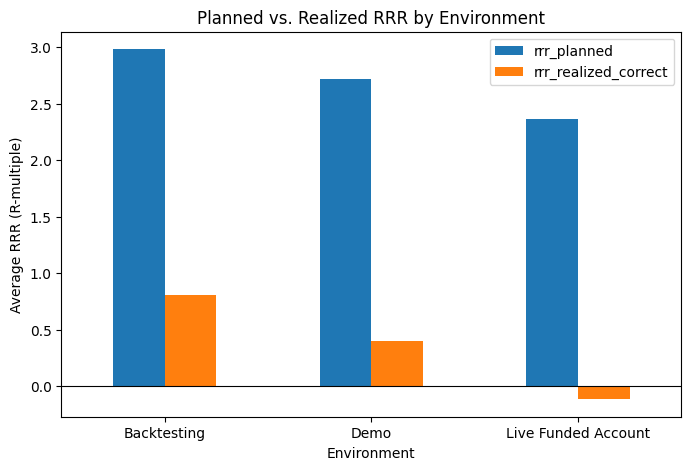

In [38]:
rrr_summary.plot(kind='bar', figsize=(8, 5))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Planned vs. Realized RRR by Environment')
plt.ylabel('Average RRR (R-multiple)')
plt.xlabel('Environment')
plt.xticks(rotation=0)
plt.show()

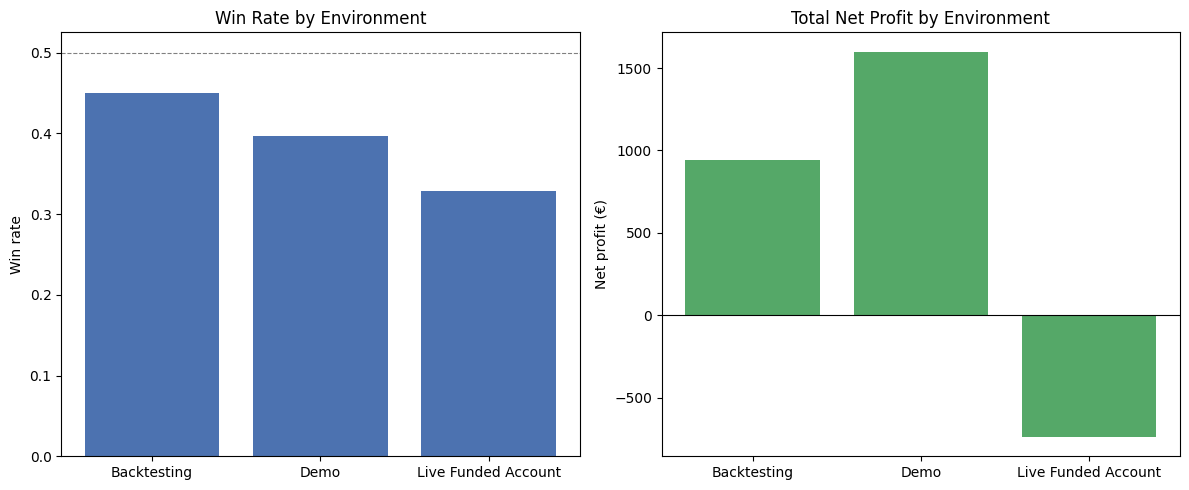

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(performance_summary.index, performance_summary['win_rate'], color='#4C72B0')
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Win Rate by Environment')
axes[0].set_ylabel('Win rate')

axes[1].bar(performance_summary.index, performance_summary['net_profit_total'], color='#55A868')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Total Net Profit by Environment')
axes[1].set_ylabel('Net profit (€)')

plt.tight_layout()
plt.show()

In [40]:
# Check average risk per trade (in euros) by environment —
# if this varies a lot, absolute profit comparisons across
# environments are misleading (bigger positions = bigger profit,
# regardless of skill)
print(df.groupby('environment')['risk_eur'].agg(['mean', 'min', 'max']))

                          mean    min     max
environment                                  
Backtesting          58.485000  49.00   68.29
Demo                 78.339559  50.49  100.00
Live Funded Account  95.727000  75.03  103.00


In [41]:
live_account = df[df['environment'] == 'Live Funded Account']

avg_win = live_account[live_account['result'] == 'W']['net_profit'].mean()
avg_loss = live_account[live_account['result'] == 'L']['net_profit'].mean()

print('Average win (€):', round(avg_win, 2))
print('Average loss (€):', round(avg_loss, 2))
print('Number of wins:', (live_account['result'] == 'W').sum())
print('Number of losses:', (live_account['result'] == 'L').sum())

Average win (€): 144.15
Average loss (€): -86.23
Number of wins: 23
Number of losses: 47


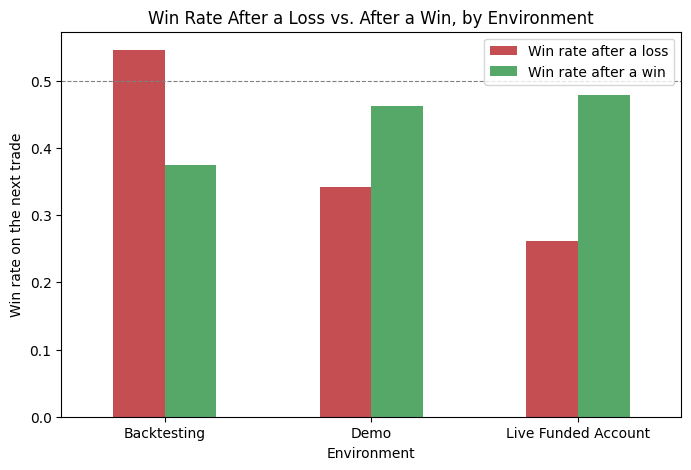

In [42]:
sequence_summary.plot(kind='bar', figsize=(8, 5), color=['#C44E52', '#55A868'])
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.title('Win Rate After a Loss vs. After a Win, by Environment')
plt.ylabel('Win rate on the next trade')
plt.xlabel('Environment')
plt.xticks(rotation=0)
plt.legend(title='')
plt.show()

## 6. Key Insights


- Execution consistently falls short of the plan across all environments — average realized RRR is far below planned RRR in every case, and turns negative (-0.12) in the Live Funded Account.
- The Live Funded Account is the weakest environment overall: the lowest win rate (32.9%), the lowest realized RRR, and the only environment with a net loss (-737€), despite having the largest number of trades (70).
- Average risk per trade increased substantially across environments (58€ in Backtesting vs. 96€ in Live Funded Account) — profit comparisons in absolute euros are not directly comparable across environments for this reason.
- Win rate drops noticeably after a loss in Demo and Live Funded Account
  (e.g. 47.8% -> 26.1% in the live account) — a possible sign of reduced
  discipline following a loss, though the sample size is small.



## 7. Conclusions & Next Steps

**Conclusions:**
- The planned RRR (2.4-3.0) suggests the strategy itself has a reasonable theoretical edge, but execution consistently fails to deliver it.
- The gap between planned and realized performance grows as the environment becomes more real — smallest in Backtesting, largest in the Live Funded Account.
- The main problem isn't strategy selection, it's discipline in execution — sticking to planned take-profit and stop-loss levels rather than exiting early.
- The post-loss win rate drop (Demo and Live Funded Account) is a discipline signal worth monitoring, not a proven pattern — the sample size (158 trades) is too small to be conclusive.


**Next Steps:**
- Build an interactive dashboard in Power BI for deeper exploration.
- Investigate whether early exits avoided larger losses or gave up real gains,
  by cross-referencing trade exits with historical price data.
- Expand the dataset with 2022 and 2025 records, if available.

In [43]:
from google.colab import files

df.to_excel('trading_2023_2024_clean.xlsx', index=False)
files.download('trading_2023_2024_clean.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>